**1. IMPORT AND UNZIP DATA**



In [ ]:
import os
import zipfile
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import scipy.io

# Path to your ZIP file
zip_path = '/content/Assignment data.zip'  # Adjust if necessary
extract_path = '/content/Assignment data'

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted to:", extract_path)

# (Optional) Check directory structure
for root, dirs, files in os.walk(extract_path):
    print("Directory:", root)
    print("Subdirectories:", dirs)
    print("Files:", files[:5])  # Show only the first 5 files
    print("-" * 50)

Files extracted to: /content/Assignment data
Directory: /content/Assignment data
Subdirectories: ['Assignment data']
Files: []
--------------------------------------------------
Directory: /content/Assignment data/Assignment data
Subdirectories: ['data']
Files: []
--------------------------------------------------
Directory: /content/Assignment data/Assignment data/data
Subdirectories: ['groundTruth', 'images']
Files: []
--------------------------------------------------
Directory: /content/Assignment data/Assignment data/data/groundTruth
Subdirectories: ['test', 'val', 'train']
Files: []
--------------------------------------------------
Directory: /content/Assignment data/Assignment data/data/groundTruth/test
Subdirectories: []
Files: ['285022.mat', '102062.mat', '326025.mat', '147077.mat', '15011.mat']
--------------------------------------------------
Directory: /content/Assignment data/Assignment data/data/groundTruth/val
Subdirectories: []
Files: ['69040.mat', '351093.mat', '3060

**2. DEFINE PATHS**

In [ ]:
base_path = '/content/Assignment data/Assignment data/data'

image_dir = os.path.join(base_path, 'images')
groundtruth_dir = os.path.join(base_path, 'groundTruth')

train_images_dir = os.path.join(image_dir, 'train')
train_groundtruth_dir = os.path.join(groundtruth_dir, 'train')

val_images_dir = os.path.join(image_dir, 'val')
val_groundtruth_dir = os.path.join(groundtruth_dir, 'val')

test_images_dir = os.path.join(image_dir, 'test')
test_groundtruth_dir = os.path.join(groundtruth_dir, 'test')


**3. PREPROCESS AND LOAD DATASET**

In [ ]:
def preprocess_image(image_path, size=(256, 256)):
    """
    Loads an image in RGB, resizes it to 'size',
    normalizes to [0,1] and returns a NumPy array of shape (h, w, 3).
    """
    img = Image.open(image_path).convert('RGB')
    if img.size != size:
        img = img.resize(size)
    img_array = np.array(img) / 255.0  # Normalize to [0,1]
    return img_array

def preprocess_boundary(gt_path, size=(256, 256), threshold=0.5):
    """
    Loads the .mat file, extracts 'Boundaries', resizes it to 'size',
    and returns a binary mask (0 or 1) for the edges.
    """
    mat = scipy.io.loadmat(gt_path)
    # Adjust indexing if your .mat structure differs
    boundaries = mat['groundTruth'][0][0][0][0]['Boundaries']

    # Resize if needed (bilinear for continuous data)
    if boundaries.shape[:2] != size:
        boundaries = np.array(
            Image.fromarray(boundaries).resize(size, resample=Image.BILINEAR)
        )
    # Binarize using the threshold
    boundary_mask = (boundaries >= threshold).astype(np.uint8)
    return boundary_mask

def load_dataset(img_dir, gt_dir, size=(256,256), threshold=0.5):
    """
    Iterates over all images in 'img_dir' and the corresponding .mat files in 'gt_dir'.
    Returns X (images) and Y (binary edge masks) as NumPy arrays.
    """
    image_paths = sorted(glob(os.path.join(img_dir, '*.jpg')))
    gt_paths = sorted(glob(os.path.join(gt_dir, '*.mat')))

    X_data, Y_data = [], []

    for img_path, gt_path in zip(image_paths, gt_paths):
        # Preprocess image
        img_array = preprocess_image(img_path, size=size)
        # Preprocess edge ground truth
        boundary_mask = preprocess_boundary(gt_path, size=size, threshold=threshold)
        # Expand dims to (h, w, 1)
        boundary_mask = np.expand_dims(boundary_mask, axis=-1)

        X_data.append(img_array)
        Y_data.append(boundary_mask)

    X_data = np.array(X_data, dtype=np.float32)
    Y_data = np.array(Y_data, dtype=np.float32)
    return X_data, Y_data

# Load train, val, and test sets
X_train, Y_train = load_dataset(train_images_dir, train_groundtruth_dir,
                                size=(256,256), threshold=0.5)
X_val,   Y_val   = load_dataset(val_images_dir,   val_groundtruth_dir,
                                size=(256,256), threshold=0.5)
X_test,  Y_test  = load_dataset(test_images_dir,  test_groundtruth_dir,
                                size=(256,256), threshold=0.5)

print("Shapes:")
print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_val:",   X_val.shape,   "Y_val:",   Y_val.shape)
print("X_test:",  X_test.shape,  "Y_test:",  Y_test.shape)


Shapes:
X_train: (200, 256, 256, 3) Y_train: (200, 256, 256, 1)
X_val: (100, 256, 256, 3) Y_val: (100, 256, 256, 1)
X_test: (200, 256, 256, 3) Y_test: (200, 256, 256, 1)


**4. IMPORTS AND CNN U-NET CONFIG**


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow.keras.backend as K

import matplotlib.pyplot as plt
import numpy as np

# -- 1.1) Weighted BCE Loss --
def weighted_bce_loss(y_true, y_pred, beta=100.0):
    """
    Weighted Binary Crossentropy to address imbalance.
      - y_true, y_pred: shape [batch, h, w, 1].
      - tf.keras.losses.binary_crossentropy collapses the last dimension -> [batch,h,w].
      - 'beta' = factor to penalize errors on the 'border' pixels more.
    """
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)  # shape [batch, h, w]
    y_true_squeeze = tf.squeeze(y_true, axis=-1)               # remove last dim -> [batch, h, w]
    weight = 1.0 + (beta - 1.0) * y_true_squeeze               # = beta where y_true=1, else 1
    wbce = weight * bce
    return tf.reduce_mean(wbce)

# -- 1.2) F1 Metric (binarized at 0.5) --
def f1_score_metric(y_true, y_pred):
    """
    Internally uses a threshold=0.5 to compute F1.
    This is just for Keras logs; for custom thresholds, we'll do offline evaluation.
    """
    y_pred_bin = tf.cast(y_pred > 0.5, tf.float32)
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred_bin, [-1])

    tp = tf.reduce_sum(y_true_f * y_pred_f)
    fp = tf.reduce_sum((1 - y_true_f) * y_pred_f)
    fn = tf.reduce_sum(y_true_f * (1 - y_pred_f))

    precision = tp / (tp + fp + 1e-7)
    recall = tp / (tp + fn + 1e-7)
    f1 = 2 * precision * recall / (precision + recall + 1e-7)
    return f1

f1_metric = tf.keras.metrics.MeanMetricWrapper(f1_score_metric, name='f1_score')

# -- 1.3) U-Net Binary Definition --
def unet_binary(input_size=(256, 256, 3)):
    inputs = layers.Input(shape=input_size)

    # Encoder
    c1 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2,2))(c2)

    # Bottleneck
    c3 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(c3)

    # Decoder
    u4 = layers.Conv2DTranspose(128, (2,2), strides=(2,2), padding='same')(c3)
    u4 = layers.concatenate([u4, c2])
    c4 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(u4)
    c4 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(c4)

    u5 = layers.Conv2DTranspose(64, (2,2), strides=(2,2), padding='same')(c4)
    u5 = layers.concatenate([u5, c1])
    c5 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c5)

    outputs = layers.Conv2D(1, (1,1), activation='sigmoid')(c5)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

**5. MODEL CREATION AND TRAINING**

In [ ]:
model = unet_binary(input_size=(256, 256, 3))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=lambda y_true,y_pred: weighted_bce_loss(y_true,y_pred,beta=100.0),
    metrics=[
        f1_metric,
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),  # Nueva métrica
        tf.keras.metrics.Recall(name='recall')          # Nueva métrica
    ]
)

# Train the model (assuming X_train, Y_train, etc. are defined)
history = model.fit(
    X_train, Y_train,
    epochs=10,
    batch_size=4,
    validation_data=(X_val, Y_val)
)


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(4, 256, 256, 3))
  warnings.warn(msg)


50/50 ━━━━━━━━━━━━━━━━━━━━ 876s 17s/step - accuracy: 0.0563 - f1_score: 0.0222 - loss: 1.4408 - precision: 0.0112 - recall: 0.9676 - val_accuracy: 0.1434 - val_f1_score: 0.0228 - val_loss: 1.3554 - val_precision: 0.0115 - val_recall: 0.9636
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 921s 17s/step - accuracy: 0.4286 - f1_score: 0.0327 - loss: 1.3417 - precision: 0.0152 - recall: 0.7948 - val_accuracy: 0.5963 - val_f1_score: 0.0382 - val_loss: 1.2464 - val_precision: 0.0188 - val_recall: 0.7467
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 913s 17s/step - accuracy: 0.6518 - f1_score: 0.0456 - loss: 1.2727 - precision: 0.0210 - recall: 0.6834 - val_accuracy: 0.8120 - val_f1_score: 0.0574 - val_loss: 1.2269 - val_precision: 0.0292 - val_recall: 0.5349
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 863s 17s/step - accuracy: 0.7132 - f1_score: 0.0514 - loss: 1.2329 - precision: 0.0250 - recall: 0.6761 - val_accuracy: 0.7223 - val_f1_score: 0.0507 - val_loss: 1.1498 - val_precision: 0.0253 - val_recall: 0.6935
Epo

**6. CUSTOM F1 AND THRESHOLD SEARCH**

In [ ]:
def compute_f1_offline(gt_mask, pred_float, threshold=0.5):
    """
    Computes F1 for a single example, given ground-truth mask and continuous prediction.
    - gt_mask: shape (h, w), binary 0/1
    - pred_float: shape (h, w), in [0..1]
    - threshold: binarization level
    """
    pred_bin = (pred_float > threshold).astype(np.uint8)
    gt_f = gt_mask.flatten()
    pred_f = pred_bin.flatten()

    tp = np.sum(gt_f * pred_f)
    fp = np.sum((1 - gt_f) * pred_f)
    fn = np.sum(gt_f * (1 - pred_f))

    prec = tp / (tp + fp + 1e-7)
    rec  = tp / (tp + fn + 1e-7)
    f1   = 2 * prec * rec / (prec + rec + 1e-7)
    return f1

def find_best_threshold(model, X_val, Y_val, thresholds=None, num_samples=None):
    """
    1) Predict over X_val (or a subset).
    2) Try various thresholds (e.g., [0.05..0.95]).
    3) Return the threshold that yields the highest average F1.
    """
    if thresholds is None:
        thresholds = np.arange(0.05, 1.0, 0.05)

    if num_samples is None or num_samples > len(X_val):
        num_samples = len(X_val)

    idxs = np.random.choice(len(X_val), size=num_samples, replace=False)
    X_sub = X_val[idxs]
    Y_sub = Y_val[idxs]

    # Continuous predictions
    preds_sub = model.predict(X_sub)  # shape (num_samples, h, w, 1)

    best_t = 0.5
    best_f1_avg = 0.0

    for t in thresholds:
        f1_list = []
        for i in range(num_samples):
            gt_mask = Y_sub[i,:,:,0]
            pred_float = preds_sub[i,:,:,0]
            f1_val = compute_f1_offline(gt_mask, pred_float, threshold=t)
            f1_list.append(f1_val)
        f1_mean = np.mean(f1_list)
        # print(f"Threshold={t}, mean F1={f1_mean}")
        if f1_mean > best_f1_avg:
            best_f1_avg = f1_mean
            best_t = t

    return best_t, best_f1_avg

**7. Validation Threshold Selection and Test Evaluation**

In [ ]:
opt_t, val_f1 = find_best_threshold(model, X_val, Y_val,
                                    thresholds=np.arange(0.05,1.0,0.05),
                                    num_samples=50)  # e.g., sample 50 images
print(f"Best threshold in val={opt_t:.2f}, F1_avg={val_f1:.4f}")

# Predict on the entire test set
preds_test = model.predict(X_test)  # shape (num_test, h, w, 1)

f1_list_test = []
for i in range(len(X_test)):
    gt_mask = Y_test[i,:,:,0]
    pred_float = preds_test[i,:,:,0]
    # Binarize with opt_t
    pred_bin = (pred_float > opt_t).astype(np.uint8)

    # Compute F1 offline
    f1_val = compute_f1_offline(gt_mask, pred_float, threshold=opt_t)
    f1_list_test.append(f1_val)

mean_f1_test = np.mean(f1_list_test)
print(f"Test F1 (threshold={opt_t:.2f}): {mean_f1_test:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(32, 256, 256, 3))
  warnings.warn(msg)


1/2 ━━━━━━━━━━━━━━━━━━━━ 36s 37s/step

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 256, 256, 3))
  warnings.warn(msg)


2/2 ━━━━━━━━━━━━━━━━━━━━ 55s 18s/step
Best threshold in val=0.80, F1_avg=0.1382
7/7 ━━━━━━━━━━━━━━━━━━━━ 198s 27s/step
Test F1 (threshold=0.80): 0.1208


**(VISUALIZE THE MODEL)**

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 18 not upgraded.


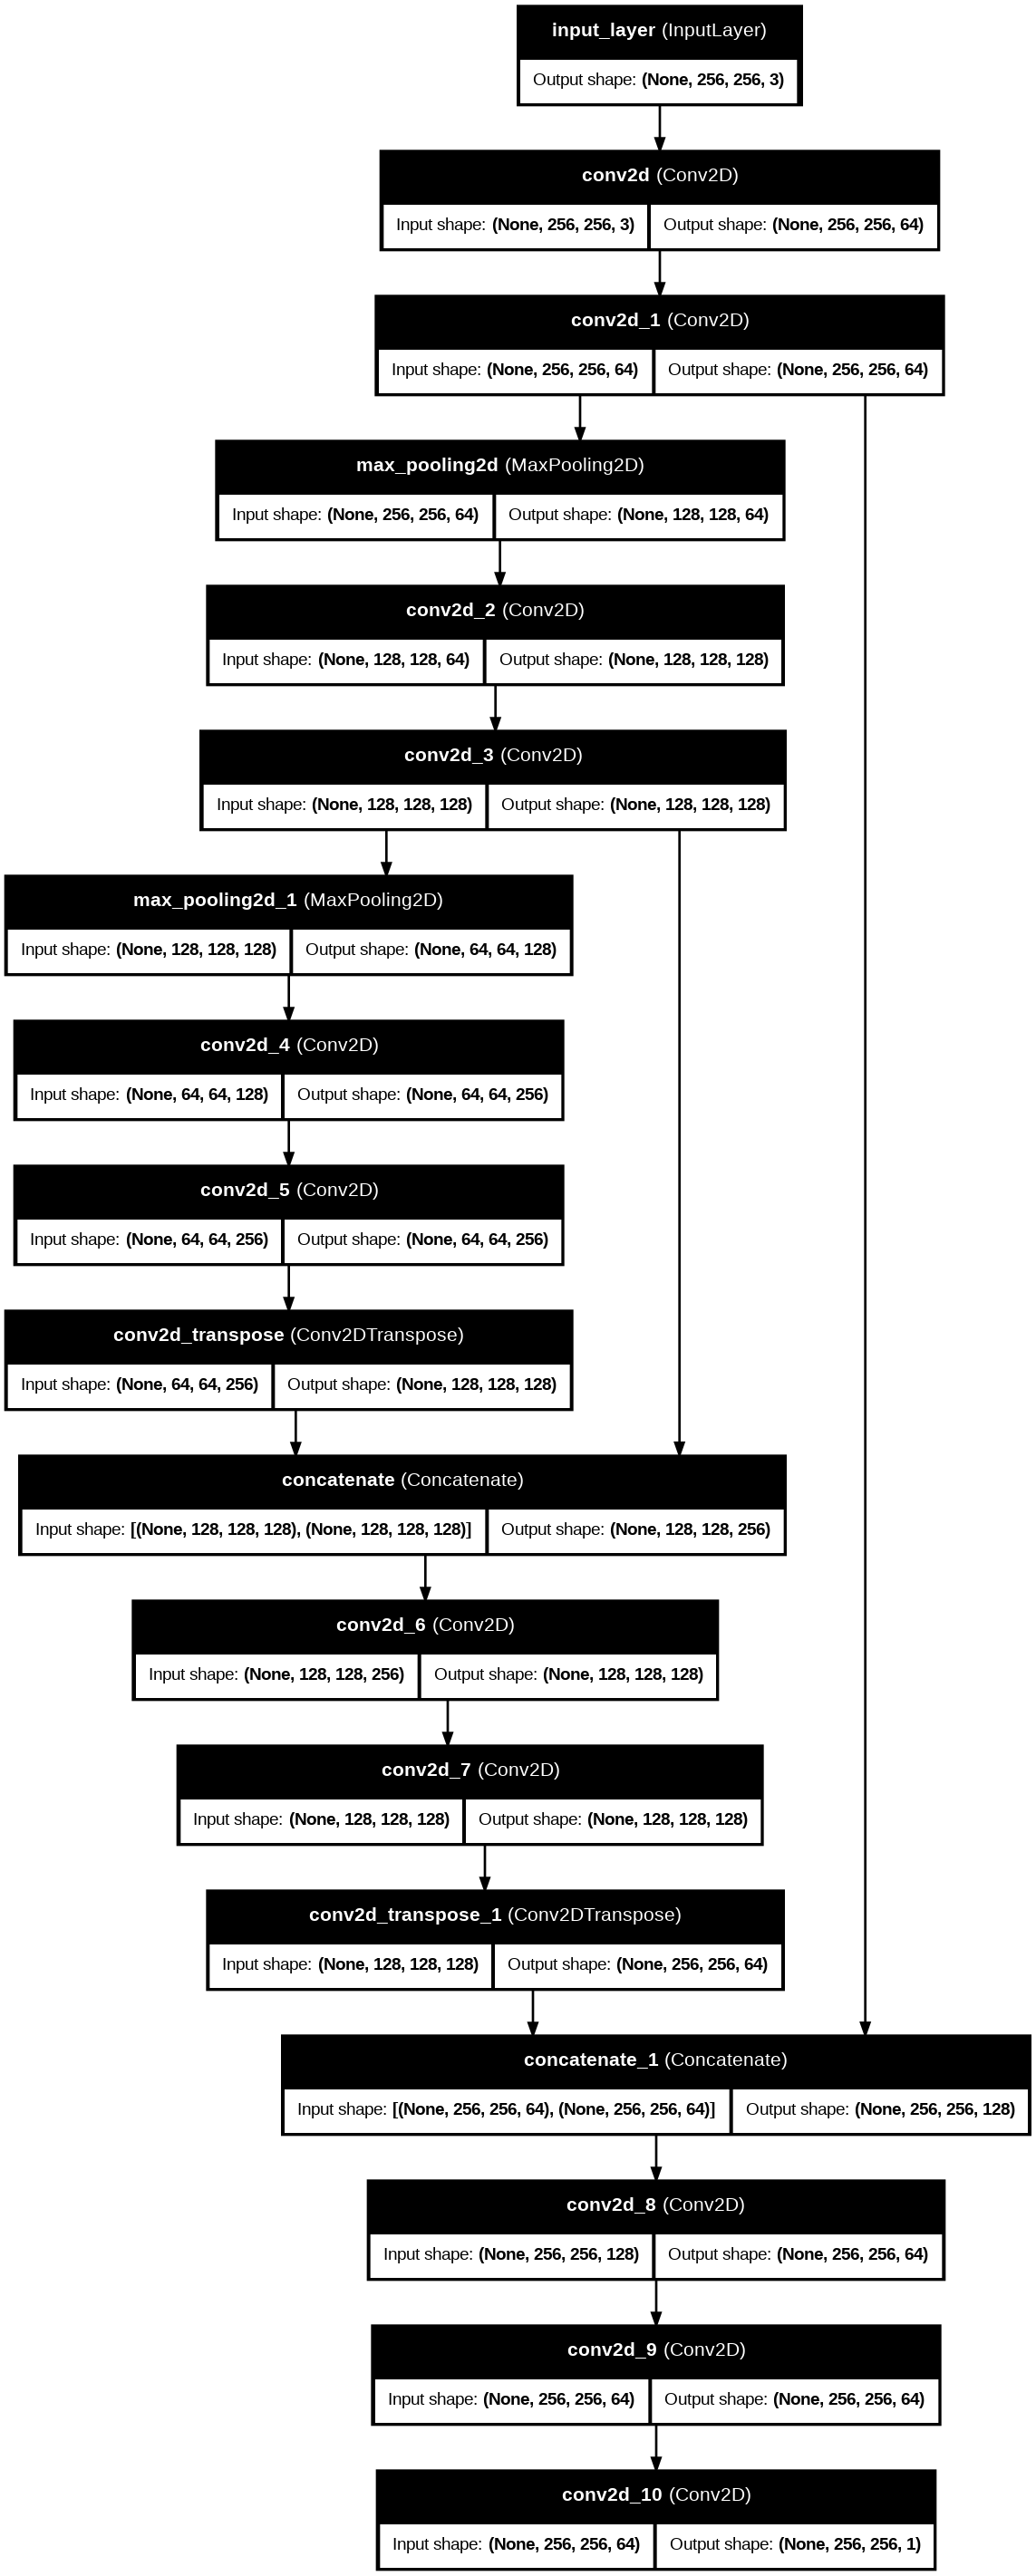

In [ ]:
# Install dependencies (only once)
!pip install pydot
!apt-get install graphviz -y

# Add to the existing code (after model.summary())
from tensorflow.keras.utils import plot_model
from IPython.display import Image

# Generate and display the visualization
plot_model(
    model,
    to_file='unet_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    expand_nested=False,
    dpi=96
)

# Display in Colab
Image(filename='unet_architecture.png', width=800)

**8. EVALUATE MODEL ON TEST AND PLOT METRICS**

dict_keys(['accuracy', 'f1_score', 'loss', 'precision', 'recall', 'val_accuracy', 'val_f1_score', 'val_loss', 'val_precision', 'val_recall'])


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 256, 256, 3))
  warnings.warn(msg)


Test - Loss: 1.1577556133270264
Test - F1:   0.07586120069026947
Test - Acc:  0.8103242516517639
Test - Precision: 0.03930651396512985
Test - Recall:    0.6544627547264099


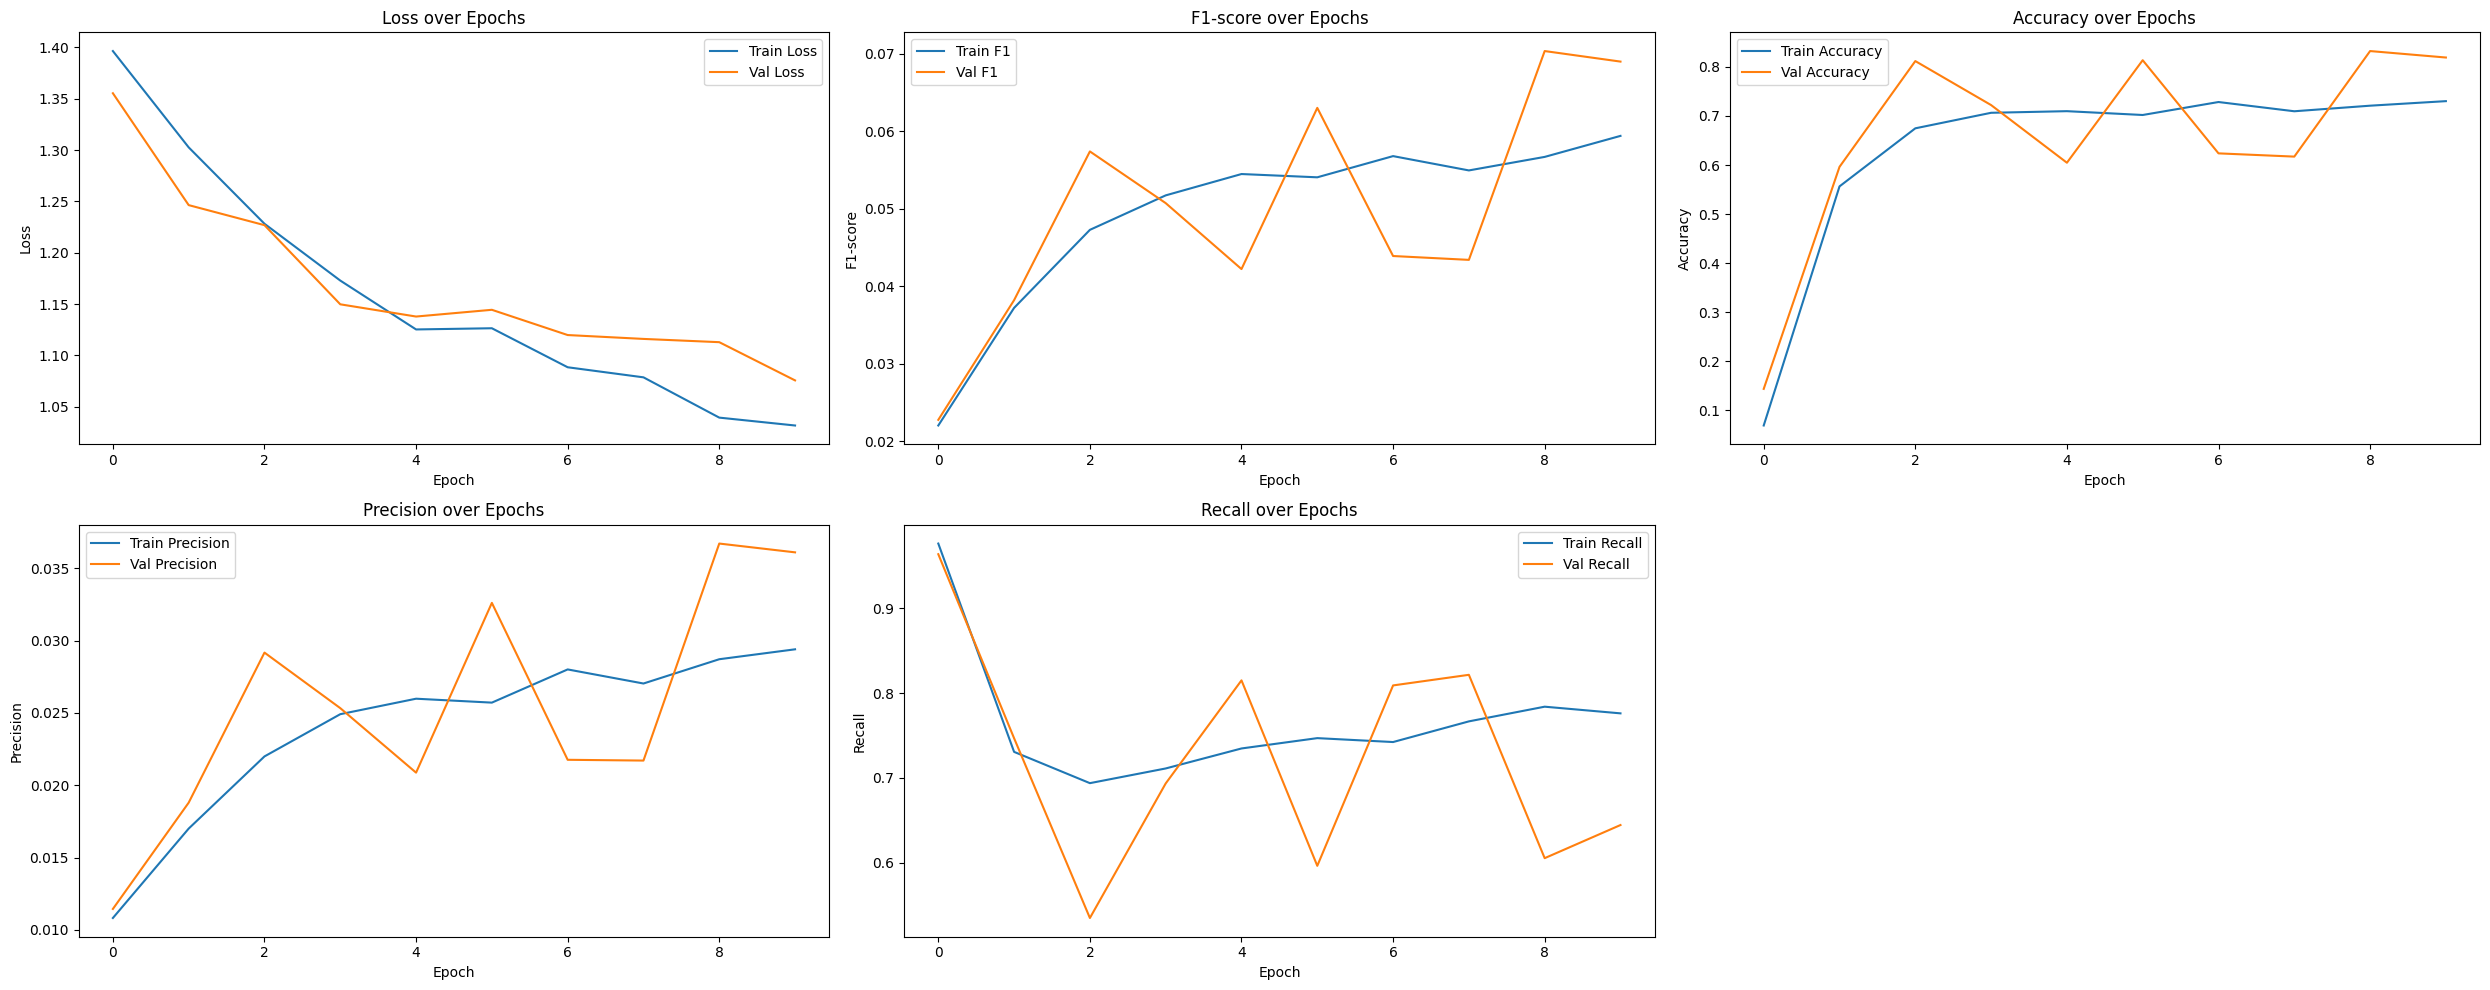

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(history.history.keys())
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

# 1) Evaluar el modelo en el conjunto de prueba
test_loss, test_f1, test_acc, test_precision, test_recall = model.evaluate(X_test, Y_test, verbose=0)
print("Test - Loss:", test_loss)
print("Test - F1:  ", test_f1)
print("Test - Acc: ", test_acc)
print("Test - Precision:", test_precision)
print("Test - Recall:   ", test_recall)

# 2) Graficar historial de entrenamiento
plt.figure(figsize=(25, 10))  # Tamaño ajustado para 5 gráficas

# -- Loss --
plt.subplot(2, 3, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# -- F1-score --
plt.subplot(2, 3, 2)
plt.plot(history.history['f1_score'], label='Train F1')  # Asume que f1_metric tiene name='f1_score'
plt.plot(history.history['val_f1_score'], label='Val F1')
plt.title('F1-score over Epochs')
plt.xlabel('Epoch')
plt.ylabel('F1-score')
plt.legend()

# -- Accuracy --
plt.subplot(2, 3, 3)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# -- Precision --
plt.subplot(2, 3, 4)
plt.plot(history.history['precision'], label='Train Precision')
plt.plot(history.history['val_precision'], label='Val Precision')
plt.title('Precision over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()

# -- Recall --
plt.subplot(2, 3, 5)
plt.plot(history.history['recall'], label='Train Recall')
plt.plot(history.history['val_recall'], label='Val Recall')
plt.title('Recall over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()

plt.tight_layout()

# Guardar y descargar
save_path = "training_history.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
files.download(save_path)

**9. Visualization of Test Examples**

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


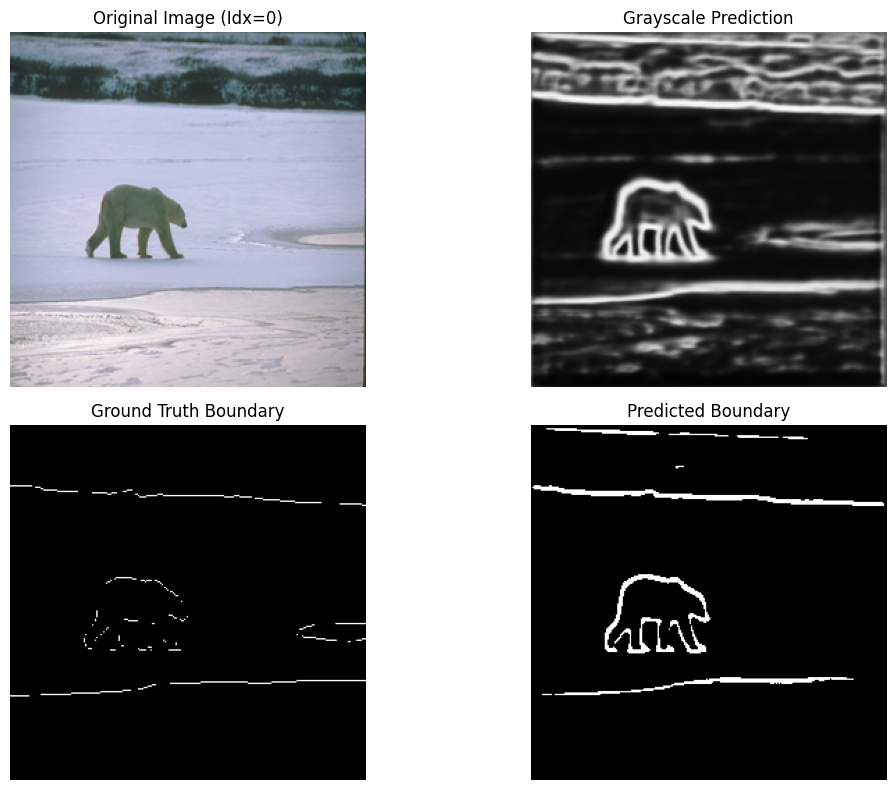

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

# Select the first test image (index=0)
idx = 0

# 1) Retrieve the test image (RGB) and the ground-truth boundary
img_test = X_test[idx]        # (256,256,3)
mask_gt  = Y_test[idx,:,:,0]  # (256,256)

# 2) Generate a continuous prediction in [0..1]
pred_float = model.predict(img_test[np.newaxis, ...])[0, :, :, 0]

# 3) Binarize with a chosen threshold
threshold = 0.85
pred_bin = (pred_float > threshold).astype(np.uint8)

# 4) Plot in a 2x2 layout:
#    - Top row: Original image, Grayscale prediction
#    - Bottom row: Ground truth boundary, Binary prediction

plt.figure(figsize=(12, 8))

# -- (1,1): Original RGB image --
plt.subplot(2, 2, 1)
plt.title("Original Image (Idx=0)")
plt.imshow(img_test)
plt.axis('off')

# -- (1,2): Grayscale prediction --
plt.subplot(2, 2, 2)
plt.title("Grayscale Prediction")
plt.imshow(pred_float, cmap='gray', vmin=0, vmax=1)
plt.axis('off')

# -- (2,1): Ground-truth boundary --
plt.subplot(2, 2, 3)
plt.title("Ground Truth Boundary")
plt.imshow(mask_gt, cmap='gray')
plt.axis('off')

# -- (2,2): Predicted boundary (binarized) --
plt.subplot(2, 2, 4)
plt.title(f"Predicted Boundary")
plt.imshow(pred_bin, cmap='gray')
plt.axis('off')

plt.tight_layout()

# Save the figure
save_path = "prediction_comparison.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

# Download the saved image
files.download(save_path)

**10. COMPARATIVE BETWEEN OUR OWN-MADE SEGMENTATION (WITH WATERSHED) VS ORIGINAL SEGMENTATION**

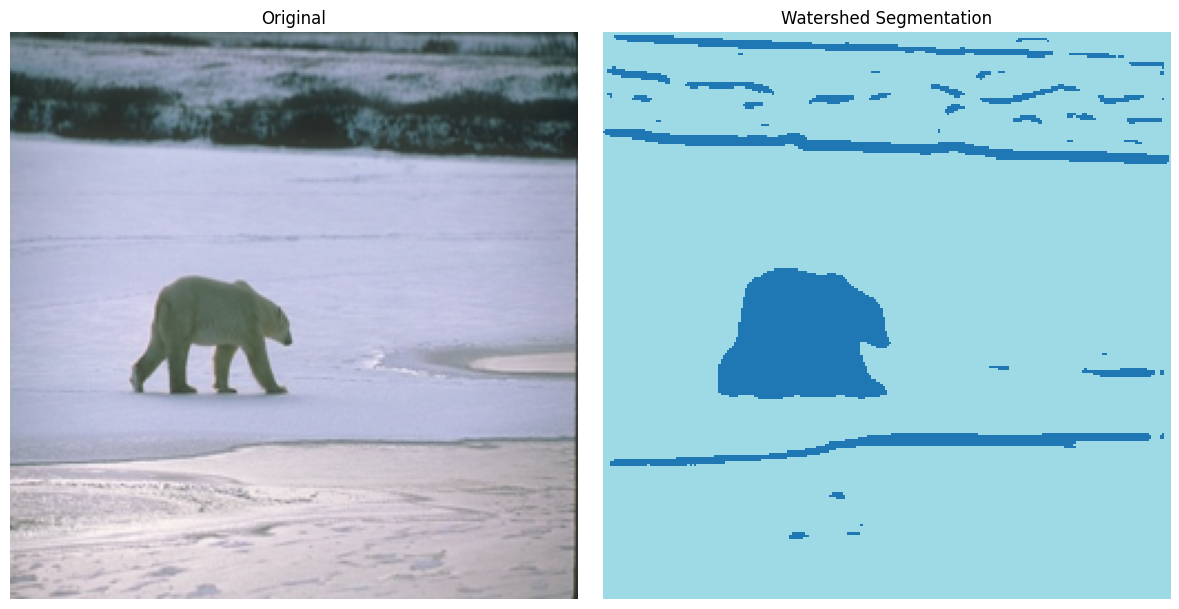

In [ ]:
from skimage.measure import label
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy import ndimage as ndi
import numpy as np
import matplotlib.pyplot as plt

def boundaries_to_segmentation_watershed(binary_boundaries):
    """
    Modified version to reduce the number of regions.
    """
    # Ensure format (N, H, W)
    if len(binary_boundaries.shape) == 4 and binary_boundaries.shape[-1] == 1:
        binary_boundaries = binary_boundaries[..., 0]

    segmentations = []
    for i in range(binary_boundaries.shape[0]):
        contour_bin = binary_boundaries[i].astype(np.uint8)
        interior = 1 - contour_bin

        # 1) Distance transform with smoothing
        distance = ndi.distance_transform_edt(interior)
        distance = ndi.gaussian_filter(distance, sigma=2)

        # 2) More restrictive peak detection
        coordinates = peak_local_max(
            distance,
            min_distance=77,
            threshold_rel=0.35,
            footprint=np.ones((70,70)),
            labels=interior
        )

        # 3) Create marker mask
        local_maxi = np.zeros(distance.shape, dtype=bool)
        local_maxi[tuple(coordinates.T)] = True

        # 4) Label markers
        markers = label(local_maxi)

        # 5) Watershed with compactness
        labels = watershed(
            -distance,
            markers,
            mask=interior,
            connectivity=2,
            compactness=0.6
        )

        segmentations.append(labels)

    return np.array(segmentations, dtype=np.int32)

# -- Apply Watershed with new threshold --
lower_threshold = 0.71  # Lower threshold
pred_bin_low = (pred_float > lower_threshold).astype(np.uint8)  # Use prediction from the first image
binary_boundaries_test = pred_bin_low[np.newaxis, ...]  # Add batch dimension

segmentations_watershed = boundaries_to_segmentation_watershed(binary_boundaries_test)

# -- Visualization function for FIRST IMAGE --
def show_first_segmentation(X, segmentations):
    """Displays only the first image"""
    idx = 0

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Original Image
    axes[0].imshow(X[idx])
    axes[0].set_title("Original")
    axes[0].axis('off')

    # Segmentation
    axes[1].imshow(segmentations[idx], cmap='tab20', interpolation='nearest')
    axes[1].set_title(f"Watershed Segmentation")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
# Display results
show_first_segmentation(X_test, segmentations_watershed)

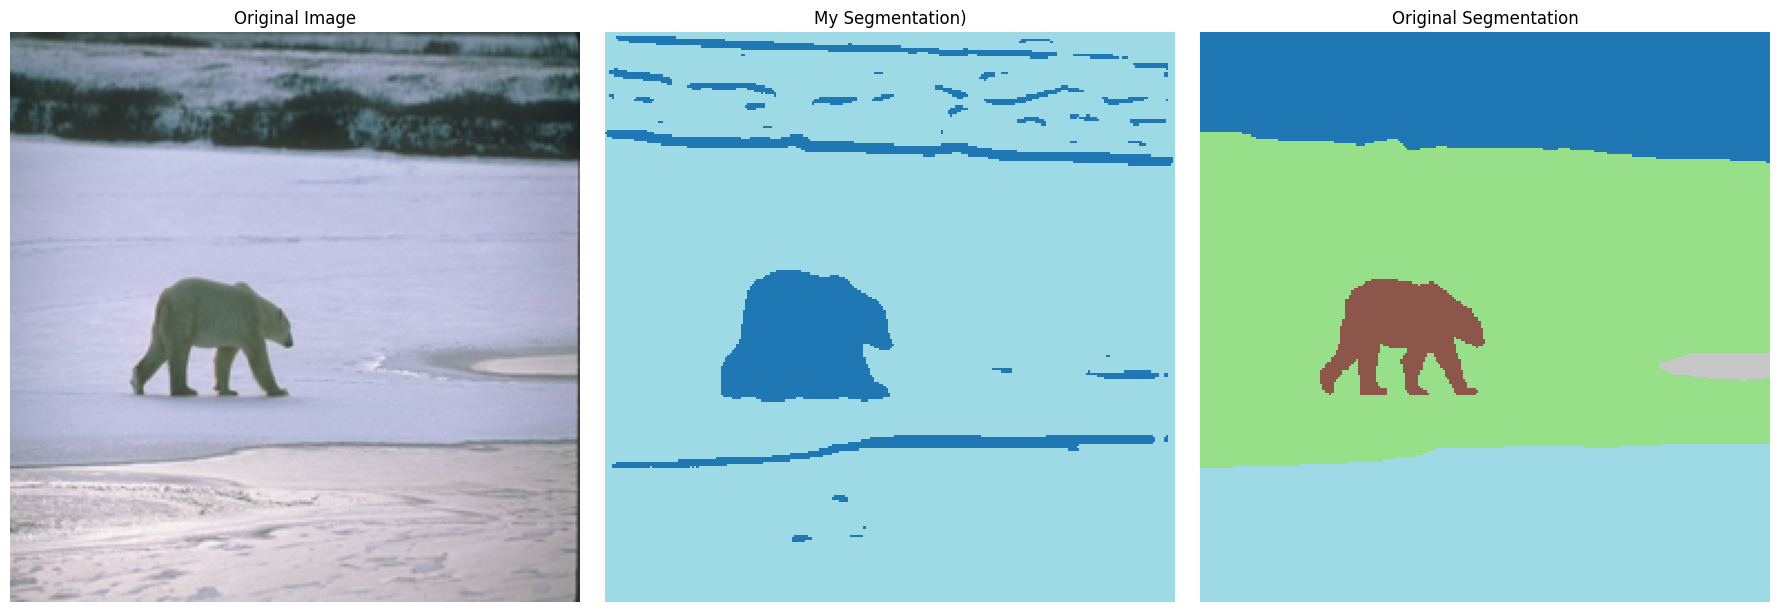

In [ ]:
from PIL import Image  # Importación necesaria

def show_and_save_segmentation(X, segmentations, save_path="segmentation_result.png"):
    """Shows watershed segmentation vs. original segmentation and saves the output."""
    idx = 0

    # Get ground truth path
    test_gt_paths = sorted(glob(os.path.join(test_groundtruth_dir, '*.mat')))
    mat_path = test_gt_paths[idx]

    # Load original segmentation from .mat
    mat = scipy.io.loadmat(mat_path)
    seg_original = mat['groundTruth'][0][0][0][0]['Segmentation']

    # Resize and preprocess (usando PIL.Image)
    seg_original = np.array(Image.fromarray(seg_original).resize((256, 256), resample=Image.NEAREST))  # Corregido

    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Original Image
    axes[0].imshow(X[idx])
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    # Watershed Segmentation
    axes[1].imshow(segmentations[idx], cmap='tab20', interpolation='nearest')
    axes[1].set_title(f"My Segmentation")
    axes[1].axis('off')

    # Original Segmentation (from .mat)
    axes[2].imshow(seg_original, cmap='tab20', interpolation='nearest')
    axes[2].set_title("Original Segmentation")
    axes[2].axis('off')

    plt.tight_layout()

    # Save the figure
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

show_and_save_segmentation(X_test, segmentations_watershed, "watershed_segmentation.png")